In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -q transformers==4.57.3 torch==2.9.0 torchvision==0.24.0 accelerate pandas bitsandbytes seaborn matplotlib protobuf

In [3]:
# import required libraries
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, Dataset, DatasetDict, concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq,
    pipeline,
    BitsAndBytesConfig
)
import time
from tqdm.auto import tqdm
import random
from collections import defaultdict
import os
import shutil
import gc
import warnings
# Suppress checkpoint warnings to maintain clean logs during iterative tuning.
warnings.filterwarnings("ignore", category=UserWarning, module="torch.utils.checkpoint")

In [4]:
# --- CONFIGURATION ---

# 1. DATA PATHS
DATA_DIR = "/content/drive/MyDrive/Research_Paper_Publication/data/transformed/"
TRAIN_FILE = os.path.join(DATA_DIR, "train_bidirectional.jsonl")
VAL_FILE = os.path.join(DATA_DIR, "val_bidirectional.jsonl")
TEST_FILE = os.path.join(DATA_DIR, "test_bidirectional.jsonl")

# 2. MODEL & OUTPUT PATHS
MODEL_NAME = "facebook/nllb-200-distilled-600M"
# LORA_OUTPUT_DIR = "/content/drive/MyDrive/Research_Paper_Publication/eval/lora-finetuned-odia-german-results-new-v1"
# FINAL_LORA_MODEL_PATH = "/content/drive/MyDrive/Research_Paper_Publication/model/lora-odia-german-translator-model-final-new-v1"
# FFT_SCORE_PATH = "/content/drive/MyDrive/Research_Paper_Publication/eval/fft_sentence_scores_updated.pkl" # PATH TO LOAD FFT SCORES

# --- Field Names ---
INPUT_FIELD = "input_text"
TARGET_FIELD = "target_text"

# --- Language Configuration ---
ODIA_LANG_CODE = "ory_Orya"
GERMAN_LANG_CODE = "deu_Latn"

# --- Task Prefixes ---
PREFIX_ORI_TO_DEU = "translate Odia to German: "
PREFIX_DEU_TO_ORI = "translate German to Odia: "

In [5]:
# --- LOAD THE DATASET (LEAKAGE-FREE METHOD) ---

print("Loading the pre-split bidirectional datasets...")

data_files = {
    "train": TRAIN_FILE,
    "validation": VAL_FILE,
    "test": TEST_FILE
}

# This loads the separate files directly into a DatasetDict
split_datasets = load_dataset("json", data_files=data_files)

print("Dataset loaded successfully.")
print(f"Training set size: {len(split_datasets['train'])}")
print(f"Validation set size: {len(split_datasets['validation'])}")
print(f"Test set size: {len(split_datasets['test'])}")

Loading the pre-split bidirectional datasets...
Dataset loaded successfully.
Training set size: 5880
Validation set size: 736
Test set size: 736


In [6]:
# --- Corpus Analysis (EDA) ---

print("\n--- Starting Corpus Analysis (EDA) ---")

# We temporarily combine them just to calculate total stats for the graphs
full_dataset_for_eda = concatenate_datasets([split_datasets['train'], split_datasets['validation'], split_datasets['test']])

print("Reconstructing original sentence pairs for analysis...")

# Extract Odia source sentences (filter for one direction to avoid duplicates in stats)
odia_source_sentences = [
    ex[INPUT_FIELD].replace(PREFIX_ORI_TO_DEU, "")
    for ex in full_dataset_for_eda
    if ex[INPUT_FIELD].startswith(PREFIX_ORI_TO_DEU)
]
german_target_sentences = [
    ex[TARGET_FIELD]
    for ex in full_dataset_for_eda
    if ex[INPUT_FIELD].startswith(PREFIX_ORI_TO_DEU)
]

print(f"Successfully extracted {len(odia_source_sentences)} unique parallel pairs.")


--- Starting Corpus Analysis (EDA) ---
Reconstructing original sentence pairs for analysis...
Successfully extracted 3676 unique parallel pairs.


In [7]:
# --- Calculate Sentence Lengths ---
odia_lengths = [len(s.split()) for s in odia_source_sentences]
german_lengths = [len(s.split()) for s in german_target_sentences]

In [8]:
# --- Descriptive Statistics ---
stats_data = {
    'Language': ['Odia', 'German'],
    'Mean Length': [np.mean(odia_lengths), np.mean(german_lengths)],
    'Median Length': [np.median(odia_lengths), np.median(german_lengths)],
    'Std. Deviation': [np.std(odia_lengths), np.std(german_lengths)],
    'Max Length': [np.max(odia_lengths), np.max(german_lengths)]
}
df_stats = pd.DataFrame(stats_data).set_index('Language')

print("\n--- Corpus Statistics ---")
display(df_stats.style.format("{:.2f}"))


--- Corpus Statistics ---


,Mean Length,Median Length,Std. Deviation,Max Length
Language,,,,
Odia,24.82,26.00,8.42,47.00
German,25.80,26.00,9.97,68.00



--- Generating Sentence Length Distribution Plot ---


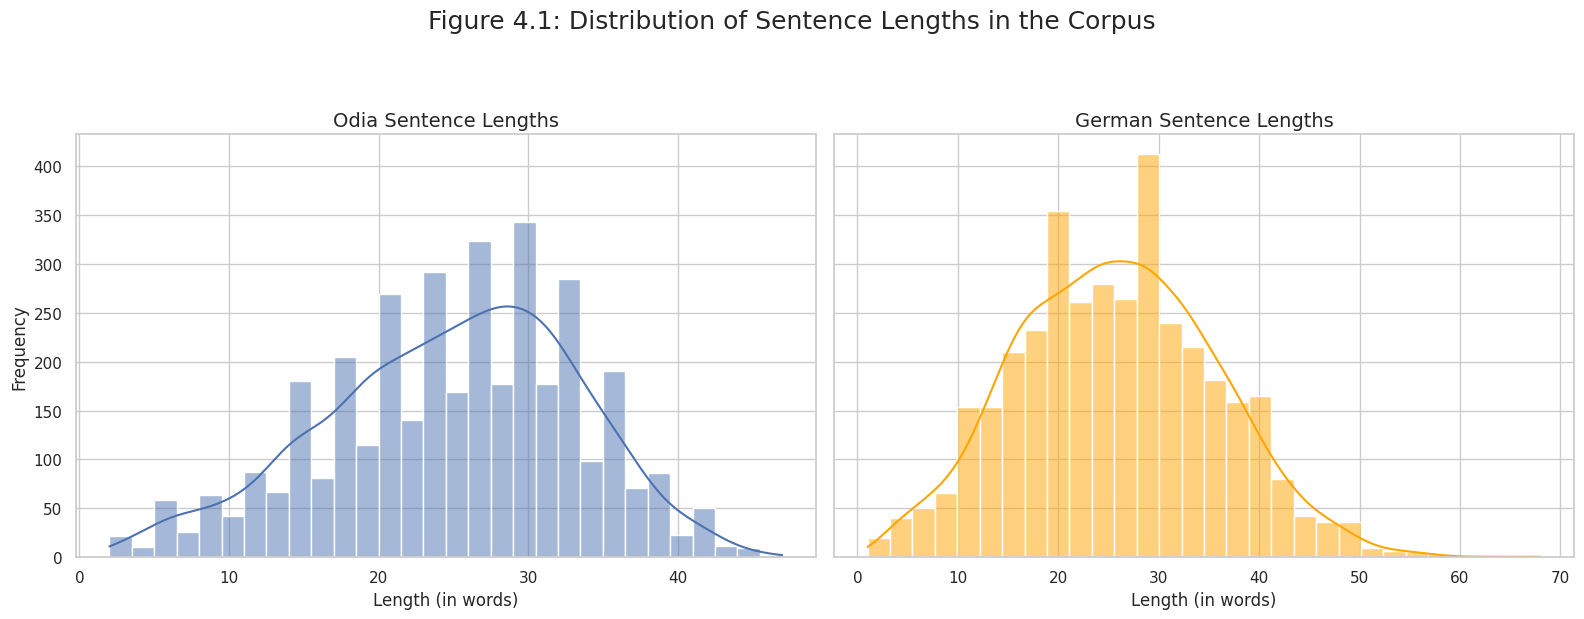


✅ Corpus Analysis complete.


In [9]:
# --- Visualize Sentence Length Distribution ---
print("\n--- Generating Sentence Length Distribution Plot ---")

plot_df_odia = pd.DataFrame({'Sentence Length (words)': odia_lengths})
plot_df_odia['Language'] = 'Odia'
plot_df_german = pd.DataFrame({'Sentence Length (words)': german_lengths})
plot_df_german['Language'] = 'German'

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Figure 4.1: Distribution of Sentence Lengths in the Corpus', fontsize=18, y=1.03)

sns.histplot(data=plot_df_odia, x='Sentence Length (words)', ax=axes[0], kde=True, bins=30)
axes[0].set_title('Odia Sentence Lengths', fontsize=14)
axes[0].set_xlabel('Length (in words)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

sns.histplot(data=plot_df_german, x='Sentence Length (words)', ax=axes[1], kde=True, bins=30, color='orange')
axes[1].set_title('German Sentence Lengths', fontsize=14)
axes[1].set_xlabel('Length (in words)', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\n✅ Corpus Analysis complete.")

In [10]:
# --- PREPARE TOKENIZER AND PREPROCESSING FUNCTION ---

print("\nLoading tokenizer...")

# Initialize the NLLB tokenizer.
# NLLB requires BCP-47 language codes (e.g., 'ory_Orya', 'deu_Latn').
# Setting src_lang and tgt_lang here ensures the tokenizer uses the correct
# special tokens (like starting the sequence with the correct language tag)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME,
                                          src_lang=ODIA_LANG_CODE,
                                          tgt_lang=GERMAN_LANG_CODE)

def preprocess_function(examples):
  """
  Tokenizes inputs and targets for Sequence-to-Sequence (Seq2Seq) training.

  This function processes a batch of raw text examples:
  1. Tokenizes the input text (Source Language) using standard encoding.
  2. Tokenizes the target text (Target Language) using the target-specific context.
  3. Formats the output to include 'input_ids', 'attention_mask', and 'labels'.

  Args:
      examples (dict): A dictionary containing 'input_text' and 'target_text'
                         lists from a dataset batch.

  Returns:
      dict: A dictionary containing the tokenized model inputs and labels.
  """
  inputs = examples[INPUT_FIELD]
  targets = examples[TARGET_FIELD]

  # Tokenize inputs (Source Language)
  # max_length=1200: Truncates sequences longer than 1200 tokens to prevent OOM errors.
  # truncation=True: Ensures strictly fixed-length or shorter sequences.
  model_inputs = tokenizer(inputs, max_length=1200, truncation=True)

  # Tokenize targets (Target Language)
  # The 'as_target_tokenizer()' context manager ensures that the tokenizer
  # uses the target language's special tokens and vocabulary settings.
  with tokenizer.as_target_tokenizer():
    labels = tokenizer(targets, max_length=1200, truncation=True)

  # Assign the tokenized target IDs to the 'labels' key.
  # The model expects 'labels' to calculate the CrossEntropyLoss during training.
  model_inputs["labels"] = labels["input_ids"]
  return model_inputs

print("Tokenizing all dataset splits...")

# Apply the preprocessing function to the entire dataset.
# batched=True: Processes examples in chunks (batch_size=16) for speed.
# remove_columns: Removes the original raw text columns ('input_text', 'target_text')
#                 so the final dataset contains only the tensors required for training.
tokenized_datasets = split_datasets.map(preprocess_function,
                                        batched=True,
                                        batch_size=16,
                                        remove_columns=split_datasets['train'].column_names)
print("Tokenization complete.")


Loading tokenizer...
Tokenizing all dataset splits...


Map:   0%|          | 0/5880 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/736 [00:00<?, ? examples/s]

Map:   0%|          | 0/736 [00:00<?, ? examples/s]

Tokenization complete.


In [11]:
# --- Vocabulary Analysis ---
def calculate_vocab_size(sentences_list, tokenizer):
  """
  Calculates the number of unique tokens (vocabulary size) present in a list of sentences.

  This function iterates through a provided corpus, tokenizes each sentence using the
  specified tokenizer, and stores the unique tokens in a set to determine the
  lexical diversity of the dataset.

  Args:
      sentences_list (list of str): A list containing the sentences to be analyzed.
      tokenizer (PreTrainedTokenizer): A tokenizer instance (e.g., from Hugging Face)
                                       that has a `.tokenize()` method.

  Returns:
      int: The total count of unique tokens found across all sentences in the list.
  """
  # Use a set to automatically handle deduplication of tokens.
  unique_tokens = set()

  print(f"Tokenizing {len(sentences_list)} sentences...")

  # Iterate through the sentences with a progress bar (tqdm) to monitor processing speed.
  for sentence in tqdm(sentences_list):
    # Tokenize the raw sentence into subwords/tokens.
    tokens = tokenizer.tokenize(sentence)
    # Add new tokens to the set (duplicates are ignored automatically).
    unique_tokens.update(tokens)
  return len(unique_tokens)

# --- Execution ---
print("\nAnalyzing Odia corpus...")
# Calculate unique tokens for the Source Language (Odia) to understand input complexity.
odia_vocab_size = calculate_vocab_size(odia_source_sentences, tokenizer)

print("\nAnalyzing German corpus...")
# Calculate unique tokens for the Target Language (German) to understand output complexity.
german_vocab_size = calculate_vocab_size(german_target_sentences, tokenizer)

# --- Display Results ---
print("\n" + "="*50)
print(f"Unique Odia Tokens:   {odia_vocab_size}")
print(f"Unique German Tokens: {german_vocab_size}")
print("="*50)


Analyzing Odia corpus...
Tokenizing 3676 sentences...


  0%|          | 0/3676 [00:00<?, ?it/s]


Analyzing German corpus...
Tokenizing 3676 sentences...


  0%|          | 0/3676 [00:00<?, ?it/s]


Unique Odia Tokens:   2639
Unique German Tokens: 9698


### Type–Token Ratio (TTR) Calculation

In [12]:
def calculate_subword_ttr(sentences, tokenizer):
  """
  Calculates the subword-level Type–Token Ratio (TTR) for a corpus.

  This function measures lexical diversity by tokenizing each sentence
  using the specified tokenizer, collecting all generated subword tokens,
  and computing the Type–Token Ratio (TTR). TTR is defined as the ratio
  of unique subword types to the total number of subword tokens in the
  corpus.

  The function returns:
    1. The number of unique subword types.
    2. The total number of subword tokens.
    3. The Type–Token Ratio (TTR).

  Formula:
    TTR = Number of Unique Types / Total Number of Tokens

  Parameters
  ----------
  sentences : list of str
    A list of text sentences comprising the corpus to be analyzed.

  tokenizer : transformers.PreTrainedTokenizer
    A tokenizer instance used to segment sentences into subword tokens.

  Returns
  -------
  tuple
    A tuple containing:
        - unique_types (int): Number of distinct subword tokens.
        - total_tokens (int): Total number of subword tokens.
        - ttr (float): Type–Token Ratio of the corpus.
  """
  all_tokens = []

  for sentence in tqdm(sentences):
    tokens = tokenizer.tokenize(sentence)
    all_tokens.extend(tokens)

  unique_types = len(set(all_tokens))
  total_tokens = len(all_tokens)

  ttr = unique_types / total_tokens

  return unique_types, total_tokens, ttr

In [13]:
odia_types, odia_tokens, odia_ttr = calculate_subword_ttr(
    odia_source_sentences,
    tokenizer
)

deu_types, deu_tokens, deu_ttr = calculate_subword_ttr(
    german_target_sentences,
    tokenizer
)

print(f"Odia TTR = {odia_ttr:.4f}")
print(f"German TTR = {deu_ttr:.4f}")

  0%|          | 0/3676 [00:00<?, ?it/s]

  0%|          | 0/3676 [00:00<?, ?it/s]

Odia TTR = 0.0134
German TTR = 0.0560


### Moving-Average TTR (MATTR) Calculation

In [16]:
!pip install lexicalrichness

In [17]:
from lexicalrichness import LexicalRichness

text = " ".join(odia_source_sentences)

lex = LexicalRichness(text)

print(lex.ttr)
print(lex.mattr(window_size=100))
print(lex.mtld())

0.20361749217736397
0.9070520180742616
1109.0441999108575
